In [2]:
import pandas as pd
df = pd.read_csv('Test.csv')

In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [5]:
df['Ever_Married'].mode()

0    Yes
Name: Ever_Married, dtype: object

In [6]:
df['Ever_Married']=df['Ever_Married'].fillna('Yes')

In [7]:
df['Graduated'].mode()

0    Yes
Name: Graduated, dtype: object

In [8]:
df['Graduated'] = df['Graduated'].fillna('Yes')

In [9]:
df['Profession'].mode()

0    Artist
Name: Profession, dtype: object

In [10]:
df['Profession']=df['Profession'].fillna('Artist')

In [11]:
df['Work_Experience'].mean()

2.552586938083121

In [12]:
df['Work_Experience']=df['Work_Experience'].fillna(2.552586938083121)

In [13]:
df['Family_Size'].mean()

2.8253778838504378

In [14]:
df['Family_Size'] = df['Family_Size'].fillna(2.8253778838504378)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2627 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2627 non-null   object 
 5   Profession       2627 non-null   object 
 6   Work_Experience  2627 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2627 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [16]:
df.drop(columns=['Var_1'], inplace=True)

The column 'Var_1' was removed during preprocessing because its semantic meaning was not available and is an anonymised categorical feature, making it difficult to interpret during the clustering analysis. 

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2627 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2627 non-null   object 
 5   Profession       2627 non-null   object 
 6   Work_Experience  2627 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2627 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 184.8+ KB


In [18]:
df['Spending_Score'].unique()

array(['Low', 'Average', 'High'], dtype=object)

In [19]:
df['Spending_Score_num'] = df['Spending_Score'].map({
    'Low' : 0,
    'Average' : 1,
    'High' : 2
})

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  2627 non-null   int64  
 1   Gender              2627 non-null   object 
 2   Ever_Married        2627 non-null   object 
 3   Age                 2627 non-null   int64  
 4   Graduated           2627 non-null   object 
 5   Profession          2627 non-null   object 
 6   Work_Experience     2627 non-null   float64
 7   Spending_Score      2627 non-null   object 
 8   Family_Size         2627 non-null   float64
 9   Spending_Score_num  2627 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 205.4+ KB


In [21]:
col_clust = ['Age' , 'Spending_Score_num'] 
df2 = df[col_clust]

In [22]:
from sklearn.preprocessing import StandardScaler
standardiser = StandardScaler()
df2_sc = standardiser.fit_transform(df2)

In [23]:
from sklearn.cluster import KMeans
wcss = []
K = range(1,11)
for k in K:
    k_means = KMeans(n_clusters=k, random_state=0)
    k_means.fit(df2_sc)
    wcss.append(k_means.inertia_)

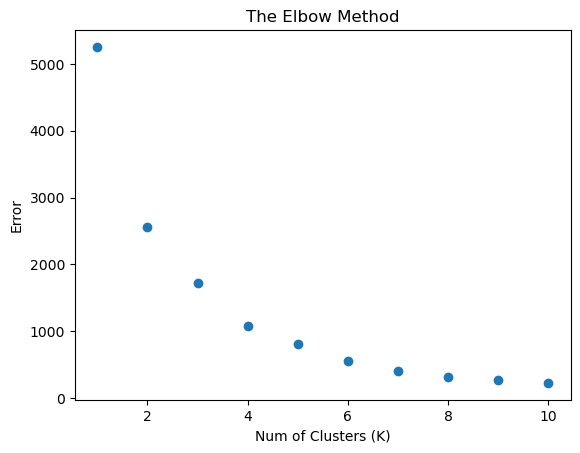

In [24]:
import matplotlib.pyplot as plt
plt.scatter(K, wcss)
plt.title('The Elbow Method')
plt.xlabel('Num of Clusters (K)')
plt.ylabel('Error')
plt.show()

I used the Elbow Method to find the best number of clusters for the clustering. I decided to split the data points into 6 clusters, since after the point at 6, the curve seems to level out and is not as steep as it was before. 

In [32]:
kmeans = KMeans(n_clusters=6, n_init=20)
clus_lab = kmeans.fit_predict(df2_sc)
df2_sc_df = pd.DataFrame(df2_sc, columns=col_clust)

In [33]:
df2_sc_df.head()

,Age,Spending_Score_num
0,-0.450948,-0.721759
1,-0.391999,0.635478
2,1.494372,-0.721759
3,0.904881,1.992715
4,-1.453083,-0.721759


In [34]:
df2 = df[col_clust].copy()
df2['labels'] = clus_lab
df2.head()

,Age,Spending_Score_num,labels
0,36,0,0
1,37,1,3
2,69,0,2
3,59,2,1
4,19,0,5


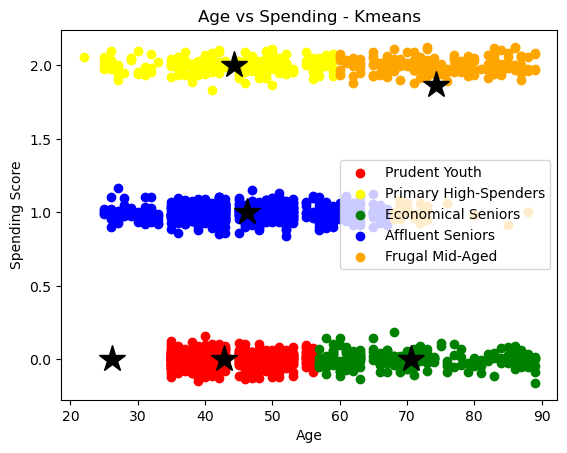

In [35]:
import numpy as np
jitt = np.random.normal(0, 0.05, size=len(df2))
df2['Spending_sc_jitt'] = df2['Spending_Score_num'] + jitt
clus_1 = df2[df2['labels'] == 0]
clus_2 = df2[df2['labels'] == 1]
clus_3 = df2[df2['labels'] == 2]
clus_4 = df2[df2['labels'] == 3]
clus_5 = df2[df2['labels'] == 4]
plt.scatter(clus_1['Age'], clus_1['Spending_sc_jitt'], label = 'Prudent Youth', color='red')
plt.scatter(clus_2['Age'], clus_2['Spending_sc_jitt'], label = 'Primary High-Spenders', color='yellow')
plt.scatter(clus_3['Age'], clus_3['Spending_sc_jitt'], label = 'Economical Seniors', color='green')
plt.scatter(clus_4['Age'], clus_4['Spending_sc_jitt'], label = 'Affluent Seniors', color='blue')
plt.scatter(clus_5['Age'], clus_5['Spending_sc_jitt'], label = 'Frugal Mid-Aged', color='orange')
plt.title('Age vs Spending - Kmeans')
plt.xlabel('Age')
plt.ylabel('Spending Score')
sc_centroids = kmeans.cluster_centers_
centr = standardiser.inverse_transform(sc_centroids)
plt.plot(centr[:,0], centr[:,1],'k*', markersize=20)
plt.legend()
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df2_sc, clus_lab)
print("Silhouette Score:", score)

Silhouette Score: 0.5760900254428023


In [42]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette Score:", silhouette_score(df2_sc, clus_lab))
print("Davies-Bouldin Index:", davies_bouldin_score(df2_sc, clus_lab))
print("Calinski-Harabasz Index:", calinski_harabasz_score(df2_sc, clus_lab))

Silhouette Score: 0.5760900254428023
Davies-Bouldin Index: 0.5814625245032331
Calinski-Harabasz Index: 4443.904041639181


Conclusion

After analysing customer behaviour, an unsupervised learning model was developed using K-Means Clustering to segment the customer base. To determine the optimal number of clusters, the Elbow Method was implemented, resulting in k = 5, allowing for the discovery of hidden behavioural patterns. 

Results

The model was successfully divided into 5 distinct personas based on the Age and Spending Score. 

Model Evaluation

The placement of the centroids - black stars indicate high cluster stability as they are centrally positioned within each group. 

Identified Segments

High Value Targets: Divided into Primary High-Spenders (Young/Mid-Aged) and Affluent Seniors. 

Budget-Conscious Segments: Divided by age into Prudent YOuth, Frugal Mid-Aged, and Economical Seniors. 

Analysis

Behavioural Trends

The most significant interpretation of thsi data is that Spending Score is a stronger seperator than Age. While customers are spread across all ages, they naturally fall into 3 distinct 'spending tiers'. 

Graph Interpretation

The Affluent Seniors (Blue) represents a highly profitable segment, proving that high spending is not limited to younger demographics.

The Prudent Youth (Red) are currently low spenders but may represent long-term growth opportunity. 

For a business, this model acts as a Targeting Engine, allowing them to tailor specific campaigns for each of the segments, improving advertising efficiency, and understanding their audience better. 